## ESTIMATION OF TREND COMPONENT: LEAST SQUARES METHOD

## Why Do We Need Trend Estimation?

Time series data consists of multiple components:

- **Trend (T)** → Long-term movement  
- **Seasonality (S)** → Repeating patterns  
- **Random/Irregular (R)** → Noise  

The **trend component** helps us:

- Understand the **overall direction** of data  
- Remove short-term fluctuations  
- Perform **forecasting**  
- Support decision-making  

Examples:
- Stock price growth  
- Mutual fund NAV trends  
- Housing sales  

---

## Method of Least Squares

- In real-world data, observations are **noisy and irregular**. 

- We need a systematic way to **fit a curve** that best represents the data.

**The key idea:**

Instead of trying to pass exactly through all points (which is impossible due to noise), we find a line that is **“closest” to all points collectively**.


The method minimizes the **total squared error**:

$$
\sum_{t=1}^{n} (Y_t - \hat{Y}_t)^2
$$

where:
- $Y_t$ → Actual value at time $t$  
- $\hat{Y}_t$ → Estimated (trend) value  
- $t$ → Time index  
- $n$ → Number of observations  

---

Why square?
- Avoids positive-negative cancellation  
- Penalizes large errors more 
---

## Trend Models

Not all data behaves the same way.

- Depending on the pattern, we choose different models.



| Model | When to Use |
|------|------------|
| Linear | Constant growth |
| Quadratic | Growth rate changing |
| Exponential | Rapid compounding growth |



- Linear → Salary increasing yearly  
- Quadratic → Acceleration (like population growth phases)  
- Exponential → Stock/mutual fund compounding  

---
$$
\text{Linear: } Y_t = \beta_0 + \beta_1 t
$$

$$
\text{Quadratic: } Y_t = a + bt + ct^2
$$

$$
\text{Exponential: } Y_t = ab^t
$$

---

## Linear Trend Model

The **simplest and most widely used model**.

- Assumes that the data changes at a **constant rate over time**.


$$
Y_t = \beta_0 + \beta_1 t
$$

where:

- $Y_t$ → Value at time $t$  
- $t$ → Time index  
- $\beta_0$ → Starting value (intercept)  
- $\beta_1$ → Rate of change (slope)  

---

### Problem:
How do we find the best values for $\beta_0$ and $\beta_1$ ??

### Solution:
Minimize total error: 
$$\text{Error}_t = Y_t - \hat{Y}_t$$

We define error at each point:
$$\text{Minimize } S = \sum_{t=1}^{n} (Y_t - \hat{Y}_t)^2$$

Replace $\hat{Y}_t:$
$$S = \sum_{t=1}^{n} (Y_t - (\beta_0 + \beta_1 t))^2$$

This function $S$ depends on $\beta_0$ and $\beta_1$.

---
Partial Derivative:

$$
\frac{\partial S}{\partial \beta_0} = 0
$$

$$
\frac{\partial S}{\partial \beta_1} = 0
$$

---
w.r.t $\beta_0$:

$$\frac{\partial S}{\partial \beta_0} = -2 \sum (Y_t - \beta_0 - \beta_1 t)$$
$$\sum (Y_t - \beta_0 - \beta_1 t) = 0$$
$$\sum Y_t - n\beta_0 - \beta_1 \sum t = 0$$
$$\sum Y_t = n\beta_0 + \beta_1 \sum t$$

w.r.t $\beta_1$:
$$\frac{\partial S}{\partial \beta_1} = -2 \sum t(Y_t - \beta_0 - \beta_1 t)$$
$$\sum t(Y_t - \beta_0 - \beta_1 t) = 0$$
$$\sum tY_t - \beta_0 \sum t - \beta_1 \sum t^2 = 0$$
$$\sum tY_t = \beta_0 \sum t + \beta_1 \sum t^2$$


- $\sum Y_t$ → Total of observations  
- $\sum t$ → Total of time indices  
- $\sum tY_t$ → Weighted sum  
- $\sum t^2$ → Sum of squared time  
- $n$ → Number of observations  

---
We now have two equations and two unknowns: $\beta_0$ and $\beta_1$:
$$\sum Y_t = n\beta_0 + \beta_1 \sum t$$
$$\sum tY_t = \beta_0 \sum t + \beta_1 \sum t^2$$
---
$$\beta_0 = \frac{\sum Y_t - \beta_1 \sum t}{n}$$
$$\beta_1 = \frac{n\sum tY_t - (\sum t)(\sum Y_t)}{n\sum t^2 - (\sum t)^2}$$
---
$$\hat{Y}_t = \beta_0 + \beta_1 t$$

- $\beta_1 > 0$ → increasing trend
- $\beta_1 < 0$ → decreasing trend

**So, least squares gives us the best possible line that minimizes total squared error.**

/Users/jerry/Documents/workspace/vscode/data_mining/dm_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed


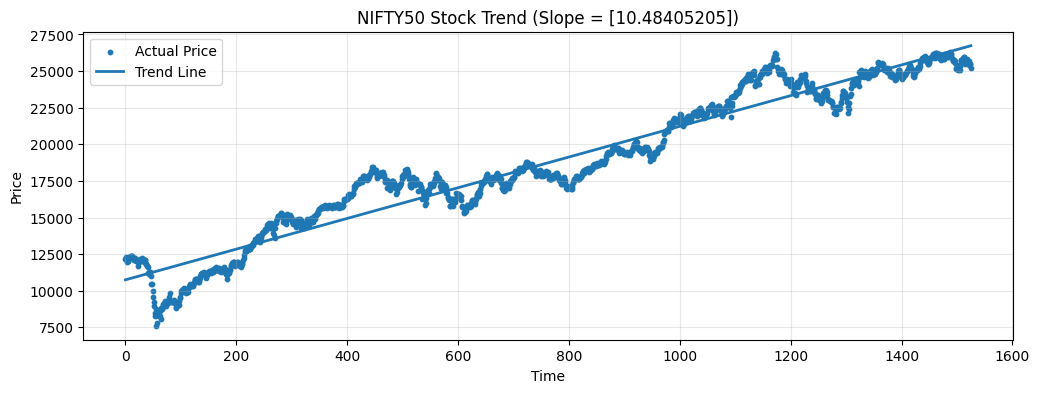

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# Download stock data (Reliance example)
df = yf.download("^NSEI", start="2020-01-01", end="2026-03-01")

# Use closing price
Y = df["Close"].values

# Time index
t = np.arange(len(Y))

# Fit line
coeff = np.polyfit(t, Y, 1)
b, a = coeff

# Prediction
Y_pred = a + b*t

# Plot
plt.figure(figsize=(12,4))

plt.scatter(t, Y, s=10, label='Actual Price')
plt.plot(t, Y_pred, linewidth=2, label='Trend Line')

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("NIFTY50 Stock Trend (Slope = " + str(b) + ")")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Forecasting

Once the trend is known, we can predict future values.

$$
\hat{Y}_{future} = \beta_0 + \beta_1 t_{future}
$$


If trend is increasing:
- Future values will continue increasing  

---

### Example: House Sales Data

We apply the method to real data to understand practical implementation.

#### Steps

1. Assign time index  
2. Compute required sums  
3. Solve for coefficients  
4. Compute trend values  
5. Calculate errors  
6. Forecast  

---

### Problem

A real estate company recorded the number of houses sold from 2010 to 2018.

| Year | Sales |
|------|------|
| 2010 | 52 |
| 2011 | 54 |
| 2012 | 48 |
| 2013 | 60 |
| 2014 | 61 |
| 2015 | 66 |
| 2016 | 70 |
| 2017 | 80 |
| 2018 | 92 |

---

## Step 1: Assign Time Index

Let:

$$
t = 1, 2, 3, \dots, 9
$$

---

## Step 2: Construct Table

| Year | $Y_t$ (Sales) | $t$ | $t^2$ | $tY_t$ |
|------|--------------|----|------|--------|
| 2010 | 52 | 1 | 1 | 52 |
| 2011 | 54 | 2 | 4 | 108 |
| 2012 | 48 | 3 | 9 | 144 |
| 2013 | 60 | 4 | 16 | 240 |
| 2014 | 61 | 5 | 25 | 305 |
| 2015 | 66 | 6 | 36 | 396 |
| 2016 | 70 | 7 | 49 | 490 |
| 2017 | 80 | 8 | 64 | 640 |
| 2018 | 92 | 9 | 81 | 828 |

---

## Step 3: Compute Sums

$$
\sum Y_t = 583
$$

$$
\sum t = 45
$$

$$
\sum t^2 = 285
$$

$$
\sum tY_t = 3203
$$

$$
n = 9
$$

---

## Step 4: Compute Slope ($\beta_1$)

$$
\beta_1 = \frac{n\sum tY_t - (\sum t)(\sum Y_t)}{n\sum t^2 - (\sum t)^2}
$$

Substitute values:

$$
\beta_1 = \frac{9 \times 3203 - (45 \times 583)}{9 \times 285 - 45^2}
$$

$$
\beta_1 = \frac{28827 - 26235}{2565 - 2025}
$$

$$
\beta_1 = \frac{2592}{540} = 4.8
$$

---

## Step 5: Compute Intercept ($\beta_0$)

$$
\beta_0 = \frac{\sum Y_t - \beta_1 \sum t}{n}
$$

$$
\beta_0 = \frac{583 - (4.8 \times 45)}{9}
$$

$$
\beta_0 = \frac{583 - 216}{9} = \frac{367}{9} = 40.78
$$

---

## Step 6: Trend Equation

$$
\hat{Y}_t = 40.78 + 4.8t
$$

---

## Step 7: Compute Trend Values

| Year | $t$ | Actual ($Y_t$) | Trend ($\hat{Y}_t$) | Error |
|------|----|---------------|------------------|--------|
| 2010 | 1 | 52 | 45.58 | 6.42 |
| 2011 | 2 | 54 | 50.38 | 3.62 |
| 2012 | 3 | 48 | 55.18 | -7.18 |
| 2013 | 4 | 60 | 59.98 | 0.02 |
| 2014 | 5 | 61 | 64.78 | -3.78 |
| 2015 | 6 | 66 | 69.58 | -3.58 |
| 2016 | 7 | 70 | 74.38 | -4.38 |
| 2017 | 8 | 80 | 79.18 | 0.82 |
| 2018 | 9 | 92 | 83.98 | 8.02 |

---

## Step 8: Forecast for 2022

### Find time index:

$$
t_{2022} = 2022 - 2009 = 13
$$

---

### Forecast:

$$
\hat{Y}_{2022} = 40.78 + 4.8 \times 13
$$

$$
\hat{Y}_{2022} = 40.78 + 62.4 = 103.18
$$

---

## Final Answer

- Trend Equation:
$$
\hat{Y}_t = 40.78 + 4.8t
$$

- Forecast for 2022:
$$
\boxed{103.18 \approx 103 \text{ houses}}
$$

---

## Interpretation

- Sales increase by **~5 houses per year**
- Strong upward trend
- Future growth expected

---

### Assumptions

- No seasonality  
- Linear relationship  
- Random errors  

### Advantages

- Simple  
- Interpretable  
- Efficient  

## Limitations

- Cannot model seasonality  
- Sensitive to outliers  
- Not suitable for nonlinear data  

---

## Quadratic Trend

In many real-world situations, the rate of increase or decrease is **not constant**.

Linear trend assumes:
- Constant increase/decrease

But in reality:
- Growth may **accelerate**
- Growth may **slow down**

### Examples

- Stock market bubbles  
- Population growth phases  
- Technology adoption curves  

---

## Model

For a **quadratic trend**, we assume that the time series follows:

$$
Y_t = \beta_0 + \beta_1 t + \beta_2 t^2
$$

where:

- $\beta_0$ = intercept  
- $\beta_1$ = linear trend coefficient  
- $\beta_2$ = quadratic (curvature) coefficient  

The idea is to find $\beta_0, \beta_1, \beta_2$ such that the **sum of squared errors** is minimum.

Interpretation:
- $\beta_2 > 0$ → **accelerating growth (U-shaped curve)**  
- $\beta_2 < 0$ → **decelerating growth (inverted U)**  

---

#### How is it different from the linear trend?

Linear trend:
- Adds a fixed amount each time

Quadratic trend:
- Adds increasing/decreasing amounts over time  

> “The change in the series is not constant; it either accelerates or decelerates over time.”


## When to Use

- When data shows **curvature**
- When slope is **not constant**

---


# 1. Error Function

Let the fitted value be:

$$
\hat{Y}_t = \beta_0 + \beta_1 t + \beta_2 t^2
$$

Then the error at time $t$ is:

$$
e_t = Y_t - \hat{Y}_t = Y_t - (\beta_0 + \beta_1 t + \beta_2 t^2)
$$

The sum of squared errors is:

$$
S = \sum \left(Y_t - \beta_0 - \beta_1 t - \beta_2 t^2\right)^2
$$

We minimize $S$.

---

# 2. Partial Derivative Steps

We take partial derivatives of $S$ with respect to $\beta_0$, $\beta_1$, and $\beta_2$, and set them equal to zero.

## Partial derivative with respect to $\beta_0$

$$
\frac{\partial S}{\partial \beta_0}
=
\sum 2\left(Y_t - \beta_0 - \beta_1 t - \beta_2 t^2\right)(-1)
$$

$$
\frac{\partial S}{\partial \beta_0}
=
-2 \sum \left(Y_t - \beta_0 - \beta_1 t - \beta_2 t^2\right)
$$

Set equal to zero:

$$
\sum \left(Y_t - \beta_0 - \beta_1 t - \beta_2 t^2\right) = 0
$$

$$
\sum Y_t - n\beta_0 - \beta_1 \sum t - \beta_2 \sum t^2 = 0
$$

So:

$$
\sum Y_t = n\beta_0 + \beta_1 \sum t + \beta_2 \sum t^2
$$

---

## Partial derivative with respect to $\beta_1$

$$
\frac{\partial S}{\partial \beta_1}
=
\sum 2\left(Y_t - \beta_0 - \beta_1 t - \beta_2 t^2\right)(-t)
$$

$$
\frac{\partial S}{\partial \beta_1}
=
-2 \sum t\left(Y_t - \beta_0 - \beta_1 t - \beta_2 t^2\right)
$$

Set equal to zero:

$$
\sum t\left(Y_t - \beta_0 - \beta_1 t - \beta_2 t^2\right)=0
$$

$$
\sum tY_t - \beta_0 \sum t - \beta_1 \sum t^2 - \beta_2 \sum t^3 = 0
$$

So:

$$
\sum tY_t = \beta_0 \sum t + \beta_1 \sum t^2 + \beta_2 \sum t^3
$$

---

## Partial derivative with respect to $\beta_2$

$$
\frac{\partial S}{\partial \beta_2}
=
\sum 2\left(Y_t - \beta_0 - \beta_1 t - \beta_2 t^2\right)(-t^2)
$$

$$
\frac{\partial S}{\partial \beta_2}
=
-2 \sum t^2\left(Y_t - \beta_0 - \beta_1 t - \beta_2 t^2\right)
$$

Set equal to zero:

$$
\sum t^2\left(Y_t - \beta_0 - \beta_1 t - \beta_2 t^2\right)=0
$$

$$
\sum t^2 Y_t - \beta_0 \sum t^2 - \beta_1 \sum t^3 - \beta_2 \sum t^4 = 0
$$

So:

$$
\sum t^2 Y_t = \beta_0 \sum t^2 + \beta_1 \sum t^3 + \beta_2 \sum t^4
$$

---

# 3. Final Normal Equations

$$
\sum Y_t = n\beta_0 + \beta_1 \sum t + \beta_2 \sum t^2
$$

$$
\sum tY_t = \beta_0 \sum t + \beta_1 \sum t^2 + \beta_2 \sum t^3
$$

$$
\sum t^2 Y_t = \beta_0 \sum t^2 + \beta_1 \sum t^3 + \beta_2 \sum t^4
$$

### Quadratic Trend (Worked Example)


#### Data

| t | $Y_t$ |
|--|------|
| 1 | 2 |
| 2 | 5 |
| 3 | 10 |
| 4 | 17 |
| 5 | 26 |

---

#### Step 1: Assume Model

$$
Y_t = a + bt + ct^2
$$

---

#### Step 2: Construct Table

| t | $Y_t$ | $t^2$ | $t^3$ | $t^4$ | $tY_t$ | $t^2Y_t$ |
|--|------|------|------|------|--------|-----------|
|1|2|1|1|1|2|2|
|2|5|4|8|16|10|20|
|3|10|9|27|81|30|90|
|4|17|16|64|256|68|272|
|5|26|25|125|625|130|650|

---

#### Step 3: Compute Sums

$$
\sum Y = 60,\quad \sum t = 15,\quad \sum t^2 = 55
$$

$$
\sum t^3 = 225,\quad \sum t^4 = 979
$$

$$
\sum tY = 240,\quad \sum t^2Y = 1034
$$

---

#### Step 4: Normal Equations

$$
\sum Y = na + b\sum t + c\sum t^2
$$

$$
\sum tY = a\sum t + b\sum t^2 + c\sum t^3
$$

$$
\sum t^2Y = a\sum t^2 + b\sum t^3 + c\sum t^4
$$

---

#### Step 5: Substitute Values

$$
60 = 5a + 15b + 55c
$$

$$
240 = 15a + 55b + 225c
$$

$$
1034 = 55a + 225b + 979c
$$

---

#### Step 6: Solve (Observation Method)

Differences:

- First differences: 3, 5, 7, 9  
- Second differences: constant (=2)


**Indicates quadratic trend**

## Final Model

$$
\boxed{
Y_t = t^2 + 1
}
$$


## Interpretation

- Growth is **accelerating**
- Increase is not constant


## Exponential Trend

Some processes grow **multiplicatively**, not additively.

Instead of adding a fixed value:
- They grow by a **percentage**

#### Examples

- Stock market returns  
- Mutual fund growth  
- Inflation  
- Population growth  

---

### Model

$$
Y_t = ab^t
$$

where:
- $Y_t$ → value at time $t$  
- $t$ → time index  
- $a$ → initial value  
- $b$ → growth factor  

Interpretation:
- $b > 1$ → growth  
- $b < 1$ → decay  

---

## Problem

This model is **non-linear**, so we cannot directly apply least squares.

---

## Solution: Log Transformation

Take logarithm:

$$
\log Y_t = \log a + t \log b
$$

Let:

$$
Z_t = \log Y_t
$$

Then:

$$
Z_t = A + Bt
$$


#### Variables (After Transformation)

- $Z_t$ → log-transformed value  
- $A = \log a$  
- $B = \log b$  


#### Fitted Model

$$
\hat{Z}_t = A + Bt
$$

---

### Define Error Function

$$
S = \sum (Z_t - A - Bt)^2
$$

We minimize $S$ using least squares.

---

### Partial Derivatives

#### With respect to $A$

$$
\frac{\partial S}{\partial A}
=
-2 \sum (Z_t - A - Bt)
$$

Set to zero:

$$
\sum (Z_t - A - Bt) = 0
$$

$$
\sum Z_t - nA - B\sum t = 0
$$

---

#### With respect to $B$

$$
\frac{\partial S}{\partial B}
=
-2 \sum t(Z_t - A - Bt)
$$

Set to zero:

$$
\sum t(Z_t - A - Bt) = 0
$$

$$
\sum tZ_t - A\sum t - B\sum t^2 = 0
$$

---

### Normal Equations

Thus, the normal equations are:

$$
\sum Z_t = nA + B\sum t
$$

$$
\sum tZ_t = A\sum t + B\sum t^2
$$

---

### Solve for A and B

$$
B = \frac{n\sum tZ_t - (\sum t)(\sum Z_t)}{n\sum t^2 - (\sum t)^2}
$$

$$
A = \frac{\sum Z_t - B\sum t}{n}
$$

---

### Convert Back to Original Parameters

$$
a = e^A,\quad b = e^B
$$


### Final Model

$$
Y_t = a b^t
$$

---

### Key Insight

The normal equations for exponential trend are actually the **linear normal equations applied to log-transformed data**.

---

### Intuition

Linear:
- +5 every year  

Exponential:
- +5%, +5%, +5%  


### When to Use

- When growth is **compounding**
- When data increases rapidly over time  

## Example

### Given Data

| t | $Y_t$ |
|--|------|
| 1 | 2 |
| 2 | 4 |
| 3 | 8 |
| 4 | 16 |
| 5 | 32 |

---

## Step 1: Assume the exponential trend model

$$
Y_t = ab^t
$$

Take log on both sides:

$$
\log Y_t = \log a + t \log b
$$

Let:

$$
Z_t = \log Y_t,\quad A = \log a,\quad B = \log b
$$

So the model becomes:

$$
Z_t = A + Bt
$$

---

## Step 2: Compute all required columns

We use natural logarithm:

$$
Z_t = \log Y_t = \ln Y_t
$$

### For each row:

#### For $t=1$

$$
Y_t = 2
$$

$$
Z_t = \log 2 = 0.693
$$

$$
tZ_t = 1 \times 0.693 = 0.693
$$

$$
t^2 = 1^2 = 1
$$

---

#### For $t=2$

$$
Y_t = 4
$$

$$
Z_t = \log 4 = 1.386
$$

$$
tZ_t = 2 \times 1.386 = 2.772
$$

$$
t^2 = 2^2 = 4
$$

---

#### For $t=3$

$$
Y_t = 8
$$

$$
Z_t = \log 8 = 2.079
$$

$$
tZ_t = 3 \times 2.079 = 6.237
$$

$$
t^2 = 3^2 = 9
$$

---

#### For $t=4$

$$
Y_t = 16
$$

$$
Z_t = \log 16 = 2.773
$$

$$
tZ_t = 4 \times 2.773 = 11.092
$$

$$
t^2 = 4^2 = 16
$$

---

#### For $t=5$

$$
Y_t = 32
$$

$$
Z_t = \log 32 = 3.466
$$

$$
tZ_t = 5 \times 3.466 = 17.330
$$

$$
t^2 = 5^2 = 25
$$

---

## Step 3: Complete Table

| t | $Y_t$ | $Z_t=\log Y_t$ | $tZ_t$ | $t^2$ |
|--|------|---------------|-------|------|
| 1 | 2  | 0.693 | 0.693  | 1  |
| 2 | 4  | 1.386 | 2.772  | 4  |
| 3 | 8  | 2.079 | 6.237  | 9  |
| 4 | 16 | 2.773 | 11.092 | 16 |
| 5 | 32 | 3.466 | 17.330 | 25 |

---

## Step 4: Compute the sums

$$
n = 5
$$

### Sum of $t$

$$
\sum t = 1+2+3+4+5 = 15
$$

### Sum of $Z_t$

$$
\sum Z_t = 0.693 + 1.386 + 2.079 + 2.773 + 3.466
$$

$$
\sum Z_t = 10.397
$$

### Sum of $tZ_t$

$$
\sum tZ_t = 0.693 + 2.772 + 6.237 + 11.092 + 17.330
$$

$$
\sum tZ_t = 38.124
$$

### Sum of $t^2$

$$
\sum t^2 = 1+4+9+16+25
$$

$$
\sum t^2 = 55
$$

---

## Step 5: Fit the linear model

We have:

$$
Z_t = A + Bt
$$

The normal equations are:

$$
\sum Z_t = nA + B\sum t
$$

$$
\sum tZ_t = A\sum t + B\sum t^2
$$

Substitute values:

$$
10.397 = 5A + 15B
$$

$$
38.124 = 15A + 55B
$$

---

## Step 6: Find $B$

$$
B = \frac{n\sum tZ_t - (\sum t)(\sum Z_t)}{n\sum t^2 - (\sum t)^2}
$$

Substitute:

$$
B = \frac{5(38.124) - (15)(10.397)}{5(55) - (15)^2}
$$

$$
B = \frac{190.620 - 155.955}{275 - 225}
$$

$$
B = \frac{34.665}{50}
$$

$$
B = 0.6933
$$

---

## Step 7: Find $A$

$$
A = \frac{\sum Z_t - B\sum t}{n}
$$

Substitute:

$$
A = \frac{10.397 - (0.6933)(15)}{5}
$$

$$
A = \frac{10.397 - 10.3995}{5}
$$

$$
A = \frac{-0.0025}{5}
$$

$$
A \approx 0
$$

---

## Step 8: Convert back to original parameters

Since:

$$
A = \log a,\quad B = \log b
$$

we take anti-log.

### Find $a$

$$
a = e^A = e^0 = 1
$$

### Find $b$

$$
b = e^B = e^{0.6933} \approx 2
$$

---

## Step 9: Final exponential trend model

$$
Y_t = ab^t
$$

Substitute $a=1$ and $b=2$:

$$
Y_t = 1 \cdot 2^t
$$

$$
\boxed{Y_t = 2^t}
$$

---

## Step 10: Interpretation

- $a=1$ is the starting multiplier
- $b=2$ means the series is multiplied by 2 at each time step
- so the value doubles every period

Hence, this is an **exponential increasing trend**.

## Comparison of Models

| Model | Growth Type | Shape |
|------|------------|------|
| Linear | Constant | Straight line |
| Quadratic | Changing rate | Curve |
| Exponential | Percentage growth | Rapid curve |

##
> “Choosing the right trend model depends on how the data behaves over time.”



### Summary

- Linear → simple trend  
- Quadratic → captures acceleration  
- Exponential → captures compounding  


> “Least squares can be extended beyond linear models to capture more complex real-world behaviors.”

---

[*********************100%***********************]  1 of 1 completed


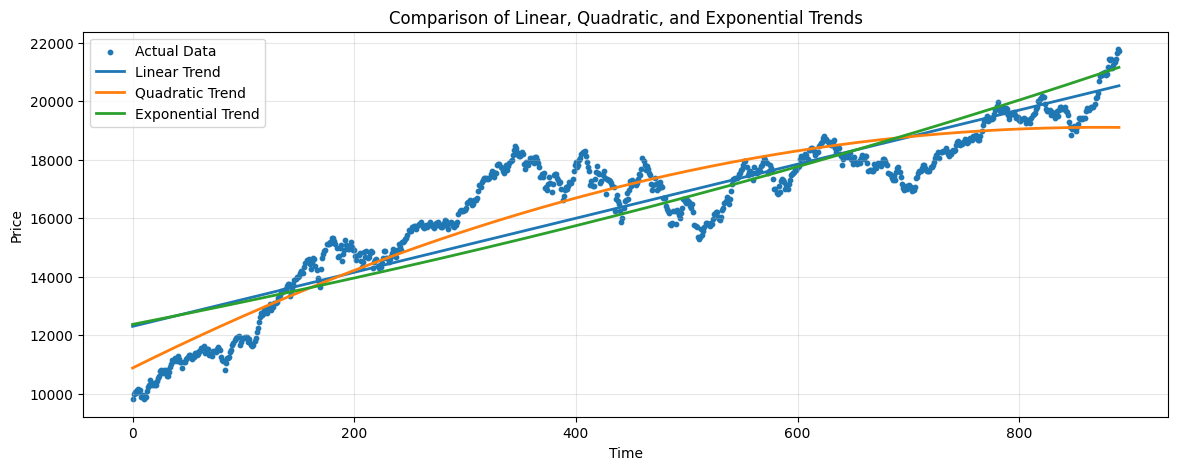

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Load stock data (NIFTY index)
df = yf.download("^NSEI", start="2020-06-01", end="2024-01-01")

# Prepare data
Y = df["Close"].values
t = np.arange(len(Y))

# -------------------------------
# 1. Linear Trend
# -------------------------------
b1, a1 = np.polyfit(t, Y, 1)
Y_linear = a1 + b1 * t

# -------------------------------
# 2. Quadratic Trend
# -------------------------------
c2, b2, a2 = np.polyfit(t, Y, 2)
Y_quad = a2 + b2 * t + c2 * (t**2)

# -------------------------------
# 3. Exponential Trend
# -------------------------------
Z = np.log(Y)  # log transform
B3, A3 = np.polyfit(t, Z, 1)

a3 = np.exp(A3)
b3 = np.exp(B3)

Y_exp = a3 * (b3 ** t)

# -------------------------------
# Plot all together
# -------------------------------
plt.figure(figsize=(14,5))

# Actual data
plt.scatter(t, Y, s=10, label="Actual Data")

# Trends
plt.plot(t, Y_linear, linewidth=2, label="Linear Trend")
plt.plot(t, Y_quad, linewidth=2, label="Quadratic Trend")
plt.plot(t, Y_exp, linewidth=2, label="Exponential Trend")

plt.title("Comparison of Linear, Quadratic, and Exponential Trends")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()